In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Tự động tạo cấu trúc thư mục lưu ảnh
os.makedirs("docs/figures", exist_ok=True)

# Đọc file (Nếu bạn upload file trực tiếp lên thư mục gốc Colab, hãy dùng tên file này)
df = pd.read_csv("penguins_size.csv")
print(df.shape)
display(df.head())
df.info()
display(df.describe(include="all"))

(344, 7)


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,334
unique,3,3,NaN,NaN,NaN,NaN,3
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


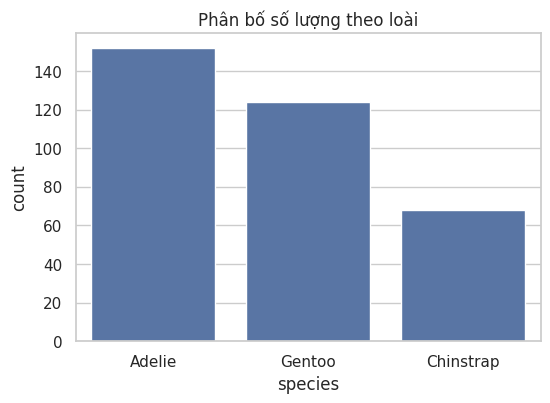

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="species", order=df["species"].value_counts().index)
plt.title("Phân bố số lượng theo loài")
plt.savefig("docs/figures/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

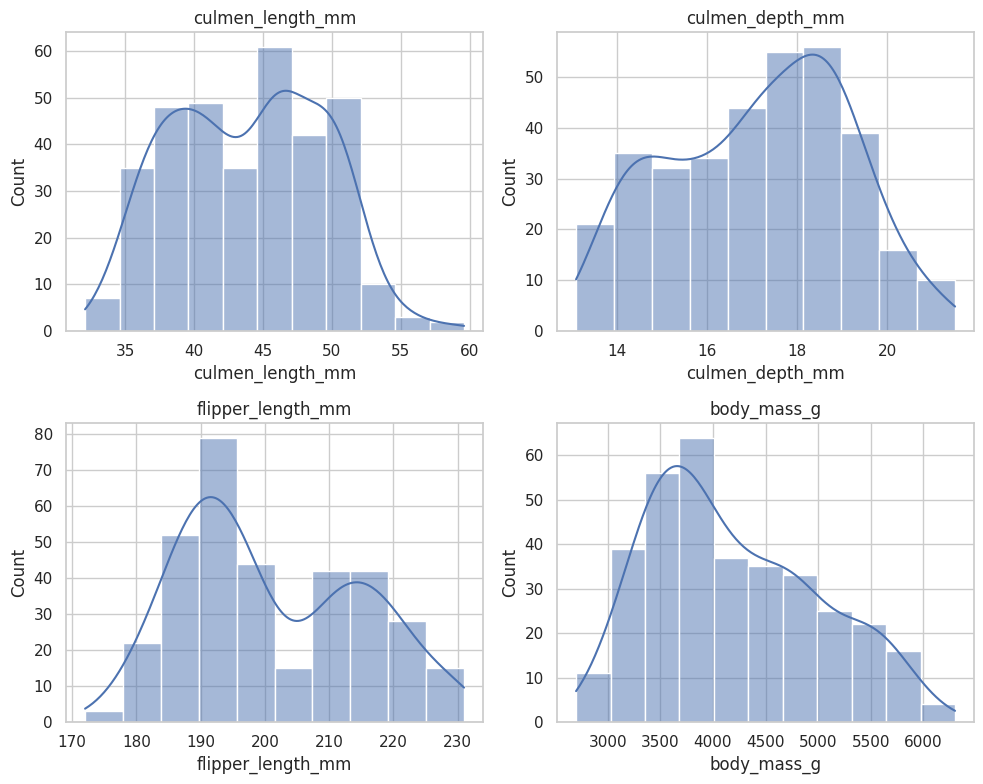

In [6]:
num_cols = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), num_cols):
  sns.histplot(df[col].dropna(), kde=True, ax=ax)
  ax.set_title(col)
plt.tight_layout()
plt.savefig("docs/figures/02_numeric_distributions.png", dpi=150)
plt.show()

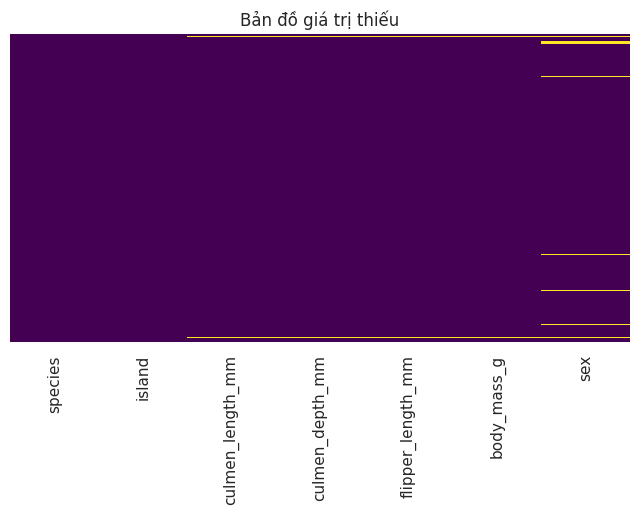

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64
Số dòng có sex = '.': 1


In [7]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Bản đồ giá trị thiếu")
plt.savefig("docs/figures/03_missing_map.png", dpi=150)
plt.show()

print(df.isnull().sum())
print("Số dòng có sex = '.':", (df["sex"] == ".").sum())

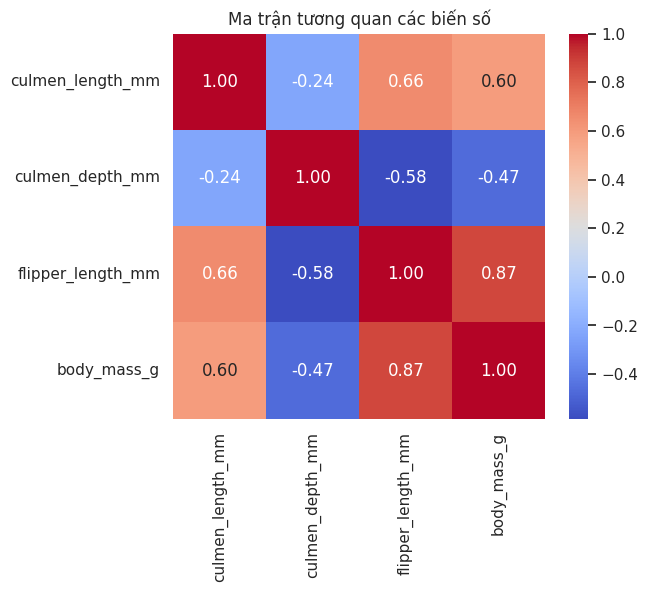

In [8]:
plt.figure(figsize=(6, 5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Ma trận tương quan các biến số")
plt.savefig("docs/figures/04_correlation_heatmap.png", dpi=150)
plt.show()

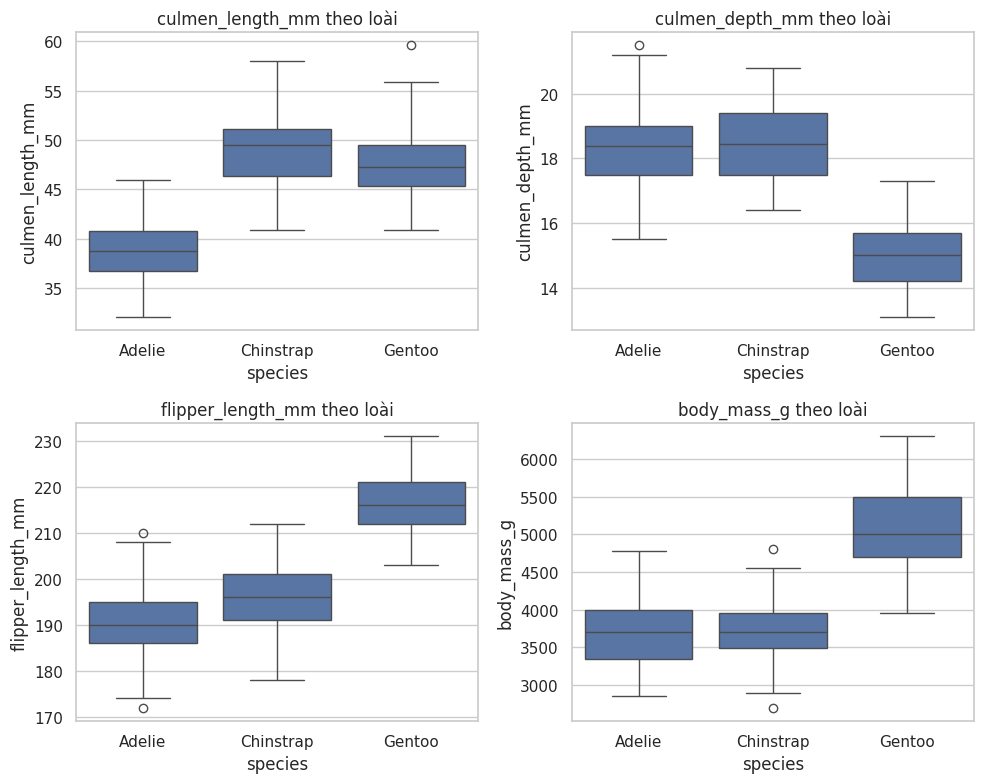

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), num_cols):
  sns.boxplot(data=df, x="species", y=col, ax=ax)
  ax.set_title(f"{col} theo loài")
plt.tight_layout()
plt.savefig("docs/figures/05_feature_vs_target_boxplot.png", dpi=150)
plt.show()

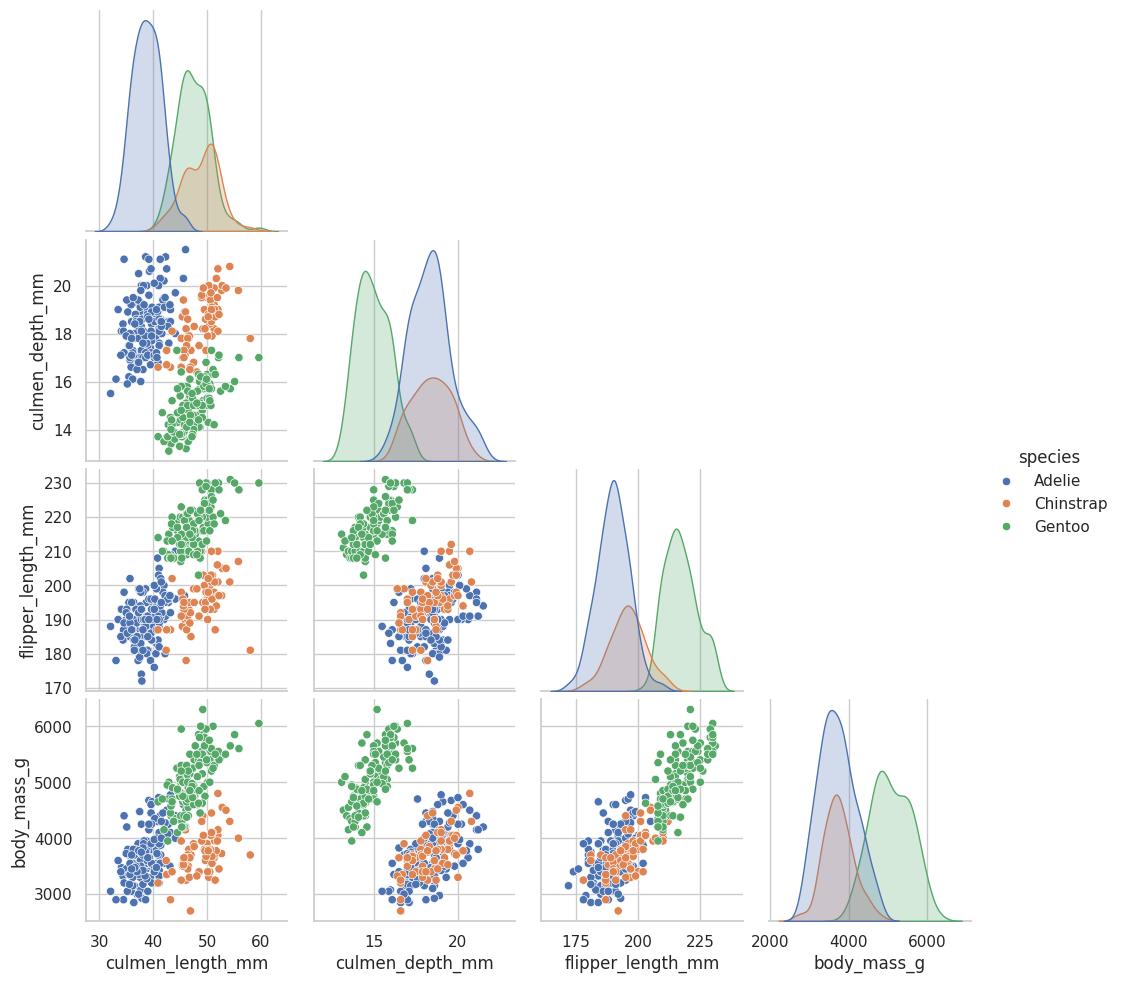

In [10]:
sns.pairplot(
    df.dropna(subset=num_cols + ["species"]), hue="species", vars=num_cols, corner=True
)
plt.savefig("docs/figures/06_pairplot.png", dpi=150)
plt.show()